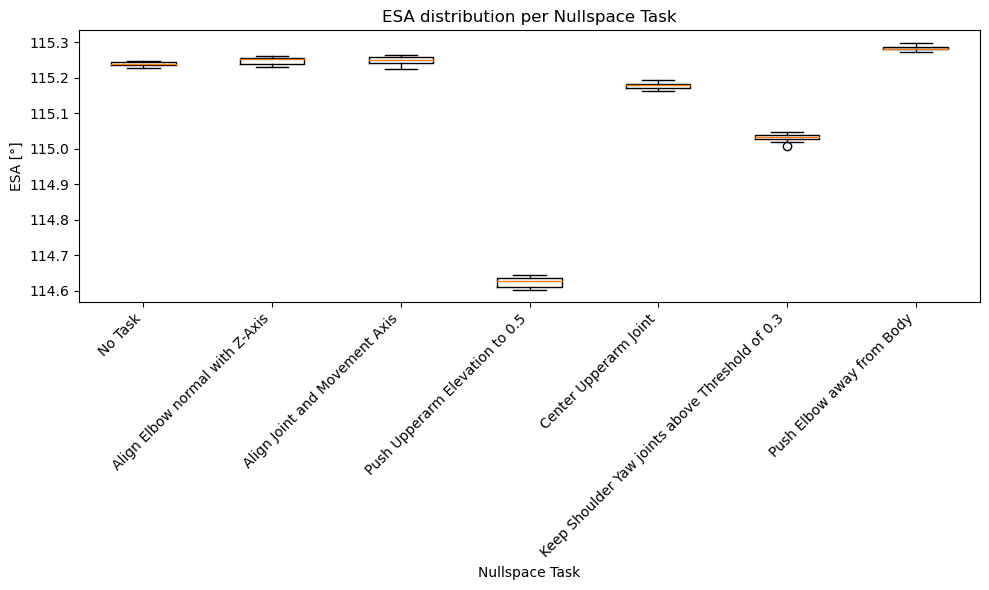

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import re
import numpy as np
import pandas as pd

# Replace with your folder path
folder = Path("/home/bjoern/Projects/Masterarbeit/simdata/nullspace_optimization")

data = {}
pattern = re.compile(r"^\s*\d+\s*:\s*([-+]?\d*\.?\d+)")

for file in sorted(folder.glob("*.txt")):
    values = []

    with open(file, "r") as f:
        for line in f:
            match = pattern.match(line)
            if match:
                values.append(float(match.group(1)))

    if values:
        data[file.stem] = values


label_map = {
    "align_joint_axis": "Align Joint and Movement Axis",
    "align_normal": "Align Elbow normal with Z-Axis",
    "arm_elevation": "Push Upperarm Elevation to 0.5",
    "center_joint": "Center Upperarm Joint",
    "no_nst": "No Task",
    "push_away_from_origin": "Push Elbow away from Body",
    "threshold": "Keep Shoulder Yaw joints above Threshold of 0.3",
}

plot_order = [
    "no_nst",
    "align_normal",
    "align_joint_axis",
    "arm_elevation",
    "center_joint",
    "threshold",
    "push_away_from_origin",
]

plot_order = [name for name in plot_order if name in data]

boxplot_data = [data[name] for name in plot_order]

labels = [label_map[name] for name in plot_order]

# Create figure
plt.figure(figsize=(10, 6))
plt.boxplot(boxplot_data, labels=labels)

plt.xlabel("Nullspace Task")
plt.ylabel("ESA [°]")
plt.title("ESA distribution per Nullspace Task")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [2]:
rows = []

for name in plot_order:
    values = np.array(data[name])
    rows.append({
        "Task": label_map[name],
        "Mean": np.mean(values),
        "Std": np.std(values)
    })

df = pd.DataFrame(rows)

# baseline mean (No Task condition)
baseline = df.loc[df["Task"] == "No Task", "Mean"].iloc[0]

target = 90.0

df["I_%"] = 100 * (baseline - df["Mean"]) / (baseline - target)

print(f"Baseline mean: {baseline:.2f}")
print(df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Baseline mean: 115.24
                                           Task    Mean   Std    I_%
                                        No Task 115.239 0.006  0.000
                 Align Elbow normal with Z-Axis 115.248 0.009 -0.039
                  Align Joint and Movement Axis 115.250 0.011 -0.044
                 Push Upperarm Elevation to 0.5 114.624 0.015  2.435
                          Center Upperarm Joint 115.179 0.009  0.237
Keep Shoulder Yaw joints above Threshold of 0.3 115.032 0.011  0.817
                      Push Elbow away from Body 115.284 0.007 -0.180
